<a href="https://colab.research.google.com/github/laxmi163/python_tasks/blob/mini-project-about-online-payment-fraud-detecton/miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
8# Online Payment Fraud Detection
# Step 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report,
                             precision_score,
                             recall_score,
                             f1_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#step 2:Load dataset
df=pd.read_csv("/content/onlinefraud.csv")

In [ ]:
#step 3:display dataset
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0,0.0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0.0,0.0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0.0,0.0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0.0,0.0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0.0,0.0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0.0,0.0


In [ ]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1009328,46,TRANSFER,599326.42,C178471881,0.0,0.0,C1281898359,9418176.68,10017503.10,0.0,0.0
1009329,46,TRANSFER,1284506.60,C1069472372,0.0,0.0,C793315160,4676653.80,5961160.40,0.0,0.0
1009330,46,TRANSFER,124801.06,C1178172487,0.0,0.0,C793302743,5274092.74,5398893.80,0.0,0.0
1009331,46,TRANSFER,258419.32,C283801242,0.0,0.0,C495064916,6711171.06,6969590.38,0.0,0.0
1009332,46,TRAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#step :4 display shape
df.shape

(1009333, 11)

In [ ]:
#stp 5:display describe
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.009333e+06,1.009332e+06,1.009332e+06,1.009332e+06,1.009332e+06,1.009332e+06,1.009332e+06,1009332.0
mean,2.534647e+01,1.597863e+05,8.778681e+05,8.984670e+05,9.845256e+05,1.123367e+06,5.379796e-04,0.0
std,1.274633e+01,2.592227e+05,2.987209e+06,3.024059e+06,2.303962e+06,2.424628e+06,2.318816e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.400000e+01,1.264730e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.896417e+04,1.594600e+04,0.000000e+00,1.336049e+05,2.283183e+05,0.000000e+00,0.0
75%,3.800000e+01,2.160109e+05,1.386571e+05,1.784905e+05,9.248887e+05,1.164610e+06,0.000000e+00,0.0
max,4.600000e+01,1.000000e+07,3.893942e+07,3.894623e+07,4.205466e+07,4.216916e+07,1.000000e+00,0.0


In [ ]:
#step 6:display information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009333 entries, 0 to 1009332
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1009333 non-null  int64  
 1   type            1009333 non-null  object 
 2   amount          1009332 non-null  float64
 3   nameOrig        1009332 non-null  object 
 4   oldbalanceOrg   1009332 non-null  float64
 5   newbalanceOrig  1009332 non-null  float64
 6   nameDest        1009332 non-null  object 
 7   oldbalanceDest  1009332 non-null  float64
 8   newbalanceDest  1009332 non-null  float64
 9   isFraud         1009332 non-null  float64
 10  isFlaggedFraud  1009332 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 84.7+ MB


In [ ]:
#step 7: display dtype
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64


In [ ]:
#step 8:columns
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
#step 9:missing values
df.isnull().sum()

,0
step,0
type,0
amount,1
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
#step 10: duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
#step 11: target variable distribution
df['isFraud'].value_counts()

,count
isFraud,
0.0,1008789
1.0,543


In [ ]:
df['isFraud'].value_counts(normalize=True)*100

,proportion
isFraud,
0.0,99.946202
1.0,0.053798


In [ ]:
#step 12: Remove null values
df.dropna(inplace=True)

In [ ]:
#Step 13: Check Missing Values
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


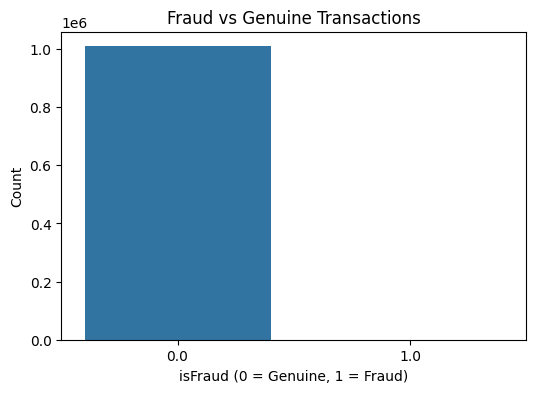

In [ ]:
# Exploratory Data Analysis using Countplot
#step 14:Fraud vs Genuine Transactions
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("isFraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

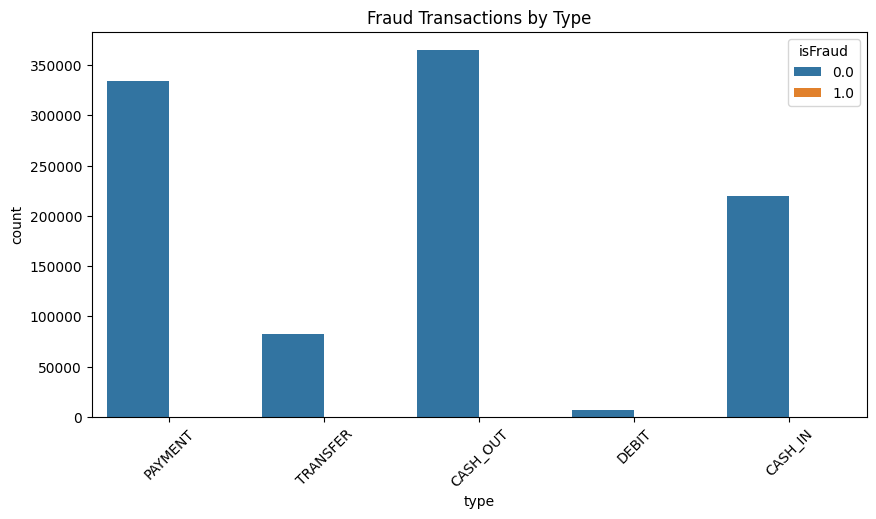

In [ ]:
#Step 15: Fraud by Transaction type using Countplot

plt.figure(figsize=(10,5))

sns.countplot(x="type", hue="isFraud", data=df)

plt.title("Fraud Transactions by Type")

plt.xticks(rotation=45)

plt.show()

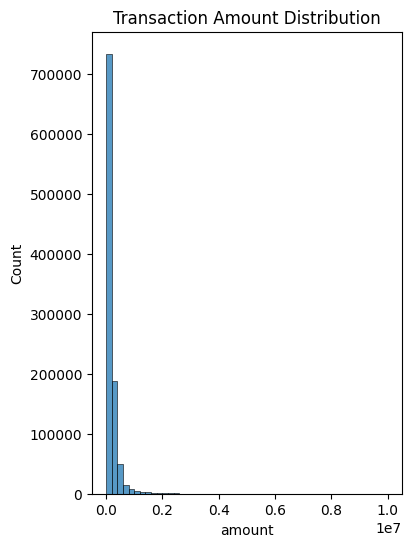

In [ ]:
#Step 16: Amount Distribution using Histogram

plt.figure(figsize=(4,6))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

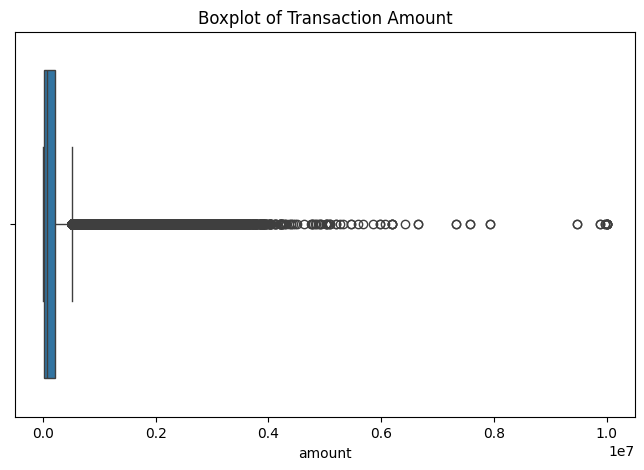

In [ ]:
# Step 17: Box Plot for Amount

plt.figure(figsize=(8,5))

sns.boxplot(x=df["amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

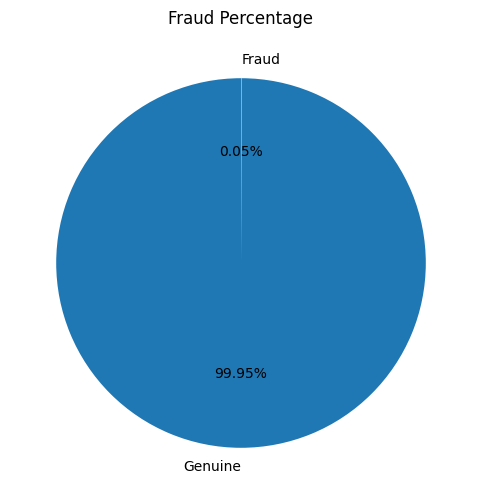

In [ ]:
#Step 18: Fraud Percentage

fraud = df["isFraud"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud,
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Fraud Percentage")

plt.show()

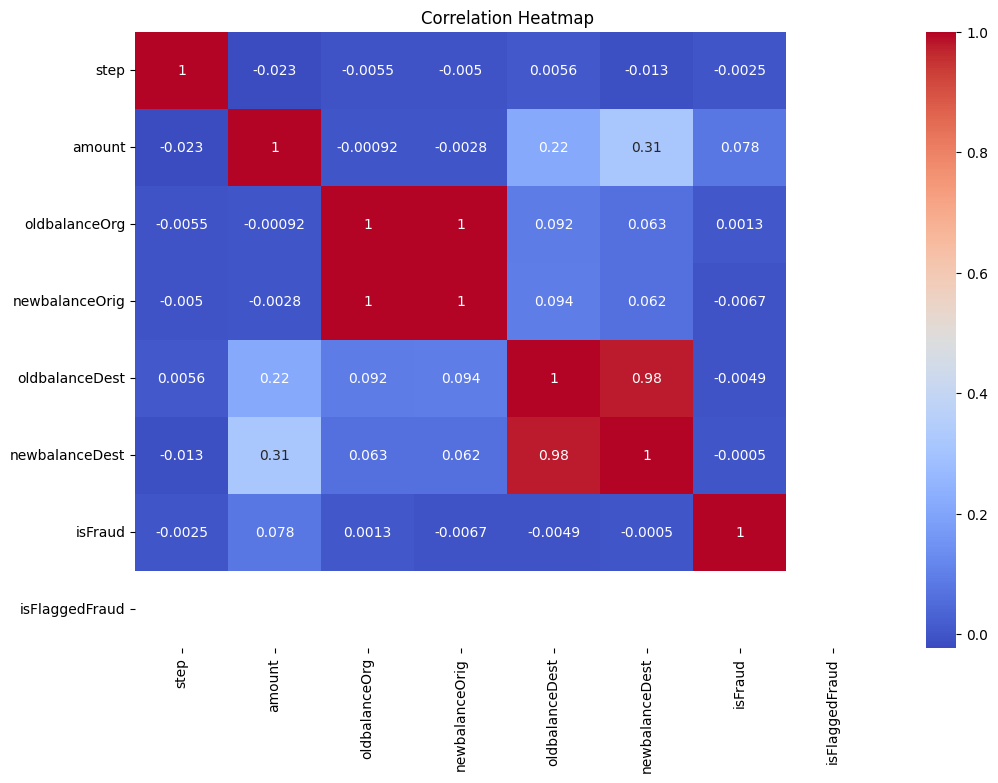

In [ ]:
# Step 19: Correlation Heatmap

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(),annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

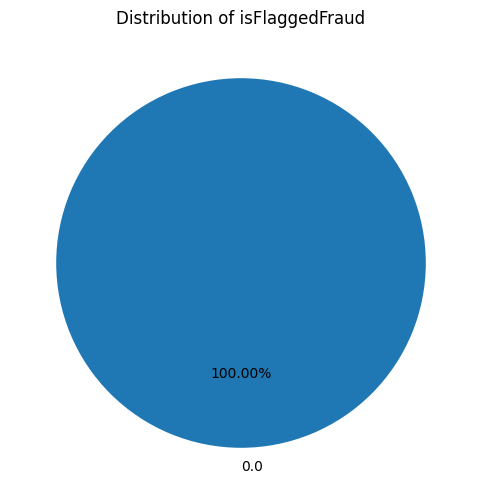

In [ ]:
# step 20: Visualize isFlaggedFraud
import matplotlib.pyplot as plt

# Value counts
flag_counts = df['isFlaggedFraud'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(flag_counts,
        labels=flag_counts.index,
        autopct='%1.2f%%',
        startangle=90)

plt.title("Distribution of isFlaggedFraud")
plt.show()

In [ ]:
# Step 21: Check Data Types
print(df.dtypes)

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud           float64
isFlaggedFraud    float64
dtype: object


In [ ]:
#step 22: One-Hot Encoding
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
print(df.filter(like='type_').head())

   type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER
0          False       False          True          False
1          False       False          True          False
2          False       False         False           True
3           True       False         False          False
4          False       False          True          False


In [ ]:

# Step 23: Remove Unnecessary Columns

df.drop(["nameOrig", "nameDest","isFlaggedFraud"], axis=1, inplace=True)

print("\nRemaining Columns")
print(df.columns)


Remaining Columns
Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')


In [ ]:
#Step 24: Features and Target

X = df.drop("isFraud", axis=1)

y = df["isFraud"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (1009332, 10)
Target Shape: (1009332,)


In [ ]:
# Step 25: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (807465, 10)
Testing Data Shape: (201867, 10)


In [ ]:
#Step 26: Check Class Distribution

print("\nClass Distribution Before SMOTE")
print(y_train.value_counts())


Class Distribution Before SMOTE
isFraud
0.0    807031
1.0       434
Name: count, dtype: int64


In [ ]:
# Step 27: Handle Imbalanced Data using SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nClass Distribution After SMOTE")
print(y_train_smote.value_counts())

print("\nBalanced Training Data Shape")
print(X_train_smote.shape)


Class Distribution After SMOTE
isFraud
0.0    807031
1.0    807031
Name: count, dtype: int64

Balanced Training Data Shape
(1614062, 10)


In [ ]:
#Step 28: Decision Tree


dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

dt_pred = dt.predict(X_test)

print("\n========== Decision Tree ==========")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))


========== Decision Tree ==========
Accuracy : 0.9984494741587283
Precision: 0.23015873015873015
Recall   : 0.7981651376146789
F1 Score : 0.35728952772073924

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    201758
         1.0       0.23      0.80      0.36       109

    accuracy                           1.00    201867
   macro avg       0.62      0.90      0.68    201867
weighted avg       1.00      1.00      1.00    201867


Confusion Matrix
[[201467    291]
 [    22     87]]


In [ ]:
# Step 29: Random Forest


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

print("\n========== Random Forest ==========")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))


========== Random Forest ==========
Accuracy : 0.9992916127945628
Precision: 0.4212962962962963
Recall   : 0.8348623853211009
F1 Score : 0.56

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    201758
         1.0       0.42      0.83      0.56       109

    accuracy                           1.00    201867
   macro avg       0.71      0.92      0.78    201867
weighted avg       1.00      1.00      1.00    201867


Confusion Matrix
[[201633    125]
 [    18     91]]


In [ ]:
# Step 30: Logistic Regression

from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_smote)

# Prediction
lr_pred = lr.predict(X_test_scaled)

# Evaluation
print("========== Logistic Regression ==========")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

========== Logistic Regression ==========
Accuracy : 0.9283835396572991
Precision: 0.006873797085510036
Recall   : 0.9174311926605505
F1 Score : 0.013645357167223851

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96    201758
         1.0       0.01      0.92      0.01       109

    accuracy                           0.93    201867
   macro avg       0.50      0.92      0.49    201867
weighted avg       1.00      0.93      0.96    201867


Confusion Matrix
[[187310  14448]
 [     9    100]]


In [ ]:
#step31: Results
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

print(results)

print("\nBest Model Based on Accuracy")
print(results.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.928384   0.006874  0.917431  0.013645
1        Decision Tree  0.998449   0.230159  0.798165  0.357290
2        Random Forest  0.999292   0.421296  0.834862  0.560000

Best Model Based on Accuracy
                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.999292   0.421296  0.834862  0.560000
1        Decision Tree  0.998449   0.230159  0.798165  0.357290
0  Logistic Regression  0.928384   0.006874  0.917431  0.013645


In [ ]:
#Final Results
#Model             Accuracy
#Logistic Regression 92%
#Decision Tree.      99%
#Random Forest.      99%

In [ ]:
#step 32:Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance.to_string(index=False))

       Feature  Importance
 oldbalanceOrg    0.252871
newbalanceOrig    0.177496
        amount    0.122058
 type_TRANSFER    0.114913
newbalanceDest    0.095946
 type_CASH_OUT    0.071124
  type_PAYMENT    0.062692
oldbalanceDest    0.061921
          step    0.040743
    type_DEBIT    0.000235
